# 1. Data Cleaning & Format

In [ ]:
import os

os.environ["HF_TOKEN"] = "Điền Hugging Face Token vào đây"

In [2]:
from src.preprocess_parquet import load_parquet, preProcess

if False:
    DROP_TOPIC = [
        'An ninh quốc gia',
        'Cán bộ, công chức, viên chức',
        'Quốc phòng',
        'Chính sách xã hội',
        'Thống kê',
        'Xây dựng pháp luật và thi hành pháp luật',
        'Tổ chức bộ máy nhà nước',
        'Ngoại giao, điều ước quốc tế',
        'Dân số, gia đình, trẻ em, bình đẳng giới',
        'Hình sự',
        'Tổ chức chính trị - xã hội, hội',
        'Tương trợ tư pháp',
        'Dân tộc',
        'Tôn giáo, tín ngưỡng',
        'Văn thư lưu trữ'
    ]

    df = load_parquet("data/dataset.parquet")
    df = df[~df['topic_title'].isin(DROP_TOPIC)]
    df = preProcess(df,save_path='data/processed_dataset.parquet')
    df

# 2. Retrieving

In [3]:
from src.preprocess_parquet import load
import pandas as pd

pd.set_option('display.width', 1000) 

df = load('data/processed_dataset.parquet')
df.head(1)

,topic_title,subject_title,article_title,content_text,content_word_count,docs_title,article_index,content_clause_count,metadata
947,Bảo hiểm,Bảo hiểm y tế,Điều 2.2.LQ.1. Phạm vi điều chỉnh và đối tượng...,"{'title': '', 'content': [{'text': '1. Luật nà...",135,25/2008/QH12|Luật số 25/2008/QH12 Bảo hiểm y t...,Điều 1,3,25/2008/QH12|Luật số 25/2008/QH12 Bảo hiểm y t...


In [4]:
from src.retrieval_pipeline import RetrievalPipeline
from src.recall_retriever import BM25Raw, BM25Hier, DenseRaw, DenseHier
from sentence_transformers import SentenceTransformer

dense_model = SentenceTransformer(
    "intfloat/multilingual-e5-small",
    token=os.environ["HF_TOKEN"]
)

print(f"[INFO] Đã nạp xong dense model lên device={dense_model.device}.")


bm25_subject = BM25Raw(text_column="subject_title")
bm25_content = BM25Raw(text_column="content_text")
bm25_hier = BM25Hier(title_include=False)
dense_content = DenseRaw(dense_model, text_column="content_text", batch_size=32)
dense_hier = DenseHier(dense_model, title_include=False, batch_size=128)

retriever = RetrievalPipeline(
    corpus = df,
    retrievalLayers=[bm25_hier, dense_content, dense_hier]
)

/mnt/082E39432E392AD8/Development Site/Code MESS/VS Code/Python/AI Guru/.UVenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 14015.76it/s]


[INFO] Đã nạp xong dense model lên device=cuda:0.
[INFO] Đang fit lớp Recall Retrieval
	 [1/3] Đang fit <class 'src.recall_retriever.BM25Hier'> với dữ liệu content_text
	 [2/3] Đang fit <class 'src.recall_retriever.DenseRaw'> với dữ liệu content_text


Batches: 100%|██████████| 1307/1307 [10:16<00:00,  2.12it/s]


	 [3/3] Đang fit <class 'src.recall_retriever.DenseHier'> với dữ liệu content_text


Batches: 100%|██████████| 1997/1997 [19:59<00:00,  1.66it/s]


# 3. Manual Evaluation

In [ ]:
score = retriever.retrieve("Các cơ sở ươm tạo và khu làm việc chung được hưởng những chính sách hỗ trợ nào về thuế và đất đai")

score_board = pd.concat([df[['metadata', 'article_index']], score], axis=1)


In [34]:
score_board.sort_values(by="dense_raw_content_text", ascending=False).head(16)

,metadata,article_index,bm25_hier,bm25_Comment,dense_raw_content_text,dense_hier,dense_Comment
8898,04/2017/QH14|Luật số 04/2017/QH14|Điều 12,Điều 12,29.308462,[2],0.909680,0.887815,[2]
17046,21/2008/QH12|Luật số 21/2008/QH12|Điều 22,Điều 22,31.022473,"[1, 1]",0.908775,0.896354,"[1, 1]"
17135,10/2024/NĐ-CP|Nghị định số 10/2024/NĐ-CP|Điều 12,Điều 12,24.174251,[2],0.895204,0.901565,[2]
17138,10/2024/NĐ-CP|Nghị định số 10/2024/NĐ-CP|Điều 15,Điều 15,41.444456,[3],0.892688,0.897995,[5]
8902,07/2020/TT-BKHCN|Thông tư số 07/2020/TT-BKHCN|...,Điều 5,23.338737,"[1, 2]",0.888460,0.870257,"[1, 2]"
17197,74/2017/NĐ-CP|Nghị định số 74/2017/NĐ-CP|Điều 12,Điều 12,23.398678,[4],0.887076,0.894945,"[2, 1]"
17199,74/2017/NĐ-CP|Nghị định số 74/2017/NĐ-CP|Điều 14,Điều 14,26.315060,[1],0.886274,0.878132,[1]
24161,40/2017/NĐ-CP|Nghị định số 40/2017/NĐ-CP|Điều 15,Điều 15,16.691173,[],0.885172,0.885172,[]
33344,153/2011/TT-BTC|Thông tư số 153/2011/TT-BTC Hư...,Điều 1,32.064753,[2],0.884816,0.882260,[2]
33372,48/2010/QH12|Luật số 48/2010/QH12|Điều 9,Điều 9,17.243890,[5],0.884672,0.878560,[7]


In [ ]:
score_board.sort_values(by="dense_hier", ascending=False).head(10)

,metadata,article_index,bm25_hier,bm25_Comment,dense_raw_content_text,dense_hier,dense_Comment
947,25/2008/QH12|Luật số 25/2008/QH12 Bảo hiểm y t...,Điều 1,11.945255,[1],0.825362,0.831763,[1]
948,70/2015/NĐ-CP|Nghị định số 70/2015/NĐ-CP Quy đ...,Điều 1,13.652594,[2],0.829322,0.829618,[2]
949,37/2015/TTLT-BYT-BTC|Thông tư liên tịch số 37/...,Điều 1,2.043773,[2],0.822043,0.831792,[2]
950,37/2015/TTLT-BYT-BTC|Thông tư liên tịch số 37/...,Điều 2,5.182709,[],0.849507,0.849507,[]
951,40/2015/TT-BYT|Thông tư số 40/2015/TT-BYT Quy ...,Điều 1,2.555635,[],0.816255,0.816255,[]
952,09/2015/TTLT-BCA-BYT-BTC|Thông tư liên tịch số...,Điều 1,2.432244,[],0.817432,0.817432,[]
953,09/2015/TTLT-BCA-BYT-BTC|Thông tư liên tịch số...,Điều 2,9.012761,"[2, 3]",0.813060,0.833584,"[2, 1]"
954,46/2016/TT-BQP|Thông tư số 46/2016/TT-BQP Quy ...,Điều 1,19.993923,[],0.820573,0.820573,[]
955,46/2016/TT-BQP|Thông tư số 46/2016/TT-BQP|Điều 2,Điều 2,18.309336,[3],0.849313,0.850260,[3]
956,85/2016/TTLT-BQP-BYT-BTC|Thông tư liên tịch số...,Điều 1,8.567668,[1],0.805006,0.834834,"[2, 1]"


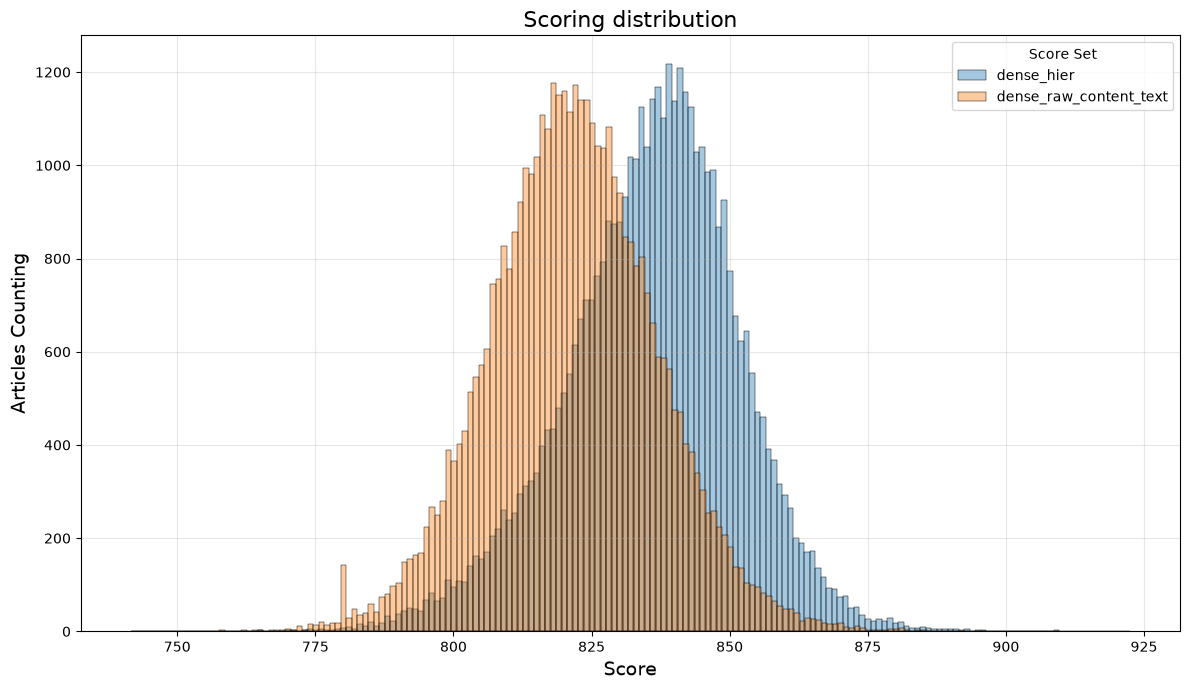

In [12]:
from src.visualize import plot_score_distributions

plot_score_distributions(columns=[score["dense_hier"]*1000, score["dense_raw_content_text"]*1000])

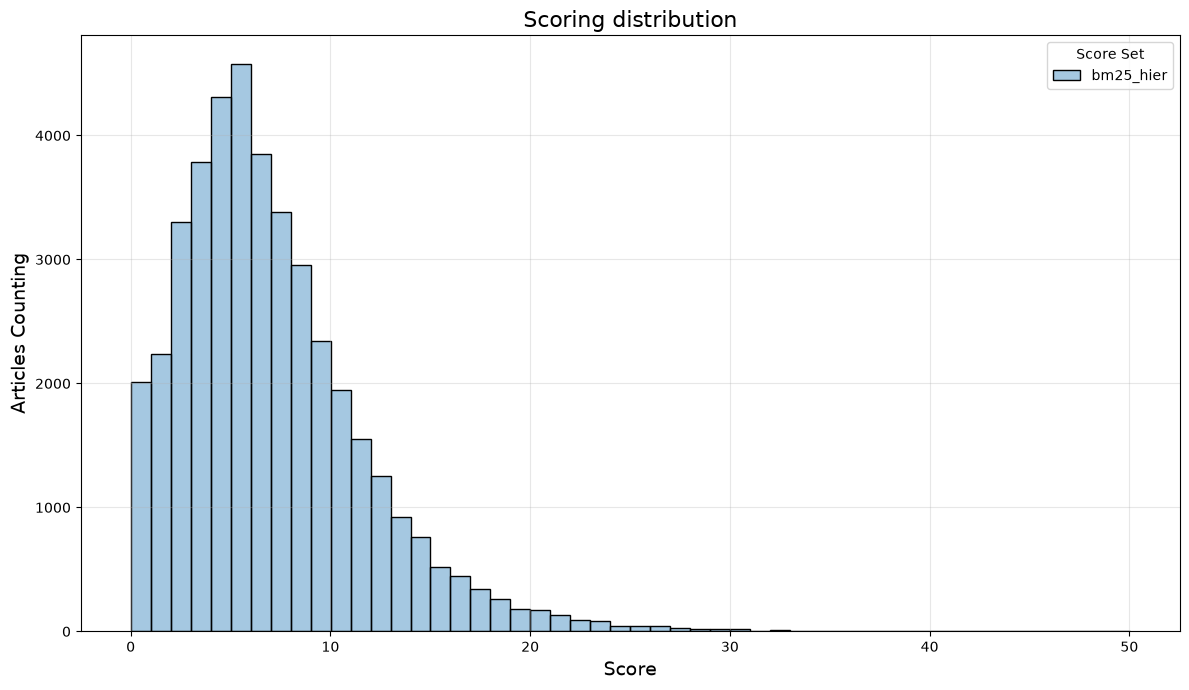

In [13]:
plot_score_distributions(columns=[score["bm25_hier"]])